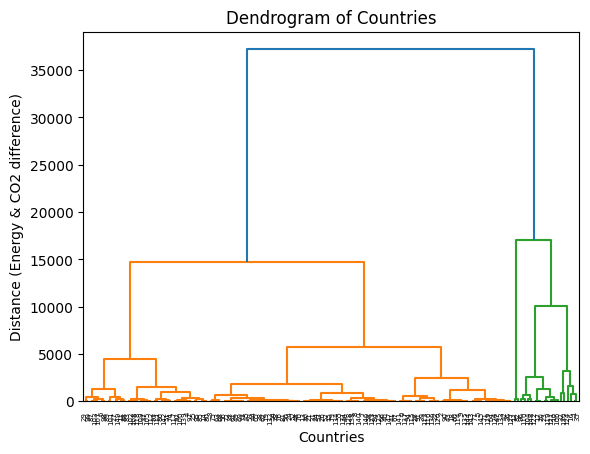

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

dt = pd.read_csv('country_energy_emissions.csv')

dt = dt.dropna(subset=[
    "Carbon dioxide emissions per capita (CO2 equivalent)",
    "Primary energy supply per capita (oil equivalent)"
])

X = dt.iloc[:, 1:3].values

import scipy.cluster.hierarchy as sch
dendrogram = sch.dendrogram(sch.linkage(X, method = 'ward'))
#linkage()→ データ同士の距離を計算してどの順番でくっつけるかを決める
#ward→Ward法...クラスタ内のばらつきが小さくなるようにくっつける階層クラスタリングの手法
#dendrogram→階層クラスタリングの結果を木の図として表示する

plt.title('Dendrogram of Countries')
plt.xlabel('Countries')
plt.ylabel('Distance (Energy & CO2 difference)')
plt.show()

#クラスタ数の決め方
#デンドログラムでは一番大きな「距離のジャンプ」の手前で切ることでクラスタ数を決めます。



In [3]:
from sklearn.cluster import AgglomerativeClustering
#階層クラスタリングのモデルを使うために読み込む
#Agglomerative「下からくっつけていく」階層クラスタリングという意味
hc = AgglomerativeClustering(n_clusters = 2, metric = 'euclidean', linkage = 'ward')
#Euclidean distance = ユークリッド距離＝普通の直線距離
y_hc = hc.fit_predict(X)

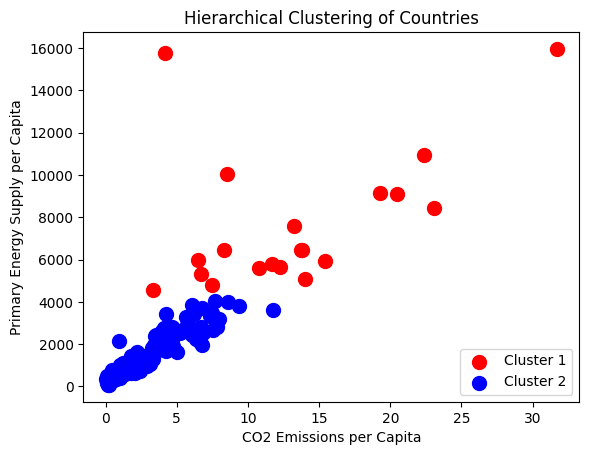

In [4]:
plt.scatter(X[y_hc == 0, 0], X[y_hc == 0, 1],
            s=100, c='red', label='Cluster 1')
#クラスタ0の行の0列目(CO2)、クラスタ0の行の1列目(エネルギー)

plt.scatter(X[y_hc == 1, 0], X[y_hc == 1, 1],
            s=100, c='blue', label='Cluster 2')

plt.title('Hierarchical Clustering of Countries')
plt.xlabel('CO2 Emissions per Capita')
plt.ylabel('Primary Energy Supply per Capita')
plt.legend()
plt.show()

"""
各国の一人当たりCO2排出量と一次エネルギー供給量を用いて階層クラスタリングを行い、国のグループ分けを試みた。
K-meansではエルボー法の折れ線グラフを目視で確認してクラスタ数を決める必要があったが、階層クラスタリングではデンドログラム（樹形図）を用いることでクラスタ構造を視覚的に確認できる点が特徴だと感じた。
そのため、折れ線グラフを見て作成者が判断するよりも、樹形図を用いた方がクラスタ数をより適切に判断しやすいと考えた。
実際に樹形図を確認した結果、今回はK-meansのときとは異なり、国は2つのグループに分けるのが妥当だと判断された。
散布図を見ると、エネルギー消費量とCO2排出量が高い国と低い国で大きく分かれており、大まかに先進国・産油国と、それ以外の国の違いを反映している可能性があると感じた。
"""